In [2]:
# import nessecary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
# import the dataset
data = pd.read_csv("C:/Users/PC Name/Desktop/Loan Prediction/Loan-Approval-Prediction-System/datasets/loan_data_new.csv")
data.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [4]:
data.shape

(45000, 14)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  object 
 2   Education            45000 non-null  object 
 3   Person Income        45000 non-null  int64  
 4   Employee Experience  45000 non-null  int64  
 5   Home Onwership       45000 non-null  object 
 6   Loan Amount          45000 non-null  int64  
 7   Loan Intent          45000 non-null  object 
 8   Loan interest Rate   45000 non-null  float64
 9   Loan percentage      45000 non-null  float64
 10  Credit History       45000 non-null  int64  
 11  Credit Score         45000 non-null  int64  
 12  Previous Loan        45000 non-null  object 
 13  Loan Status          45000 non-null  int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 4.8+ MB


## Varaible Description

1. **Age** - Age of a Person
2. **Gender** - Gender which is Male or Female
3. **Education** - What is the Educational Level
4. **Personal Income** - how much person Income
5. **Employee Experience** - How Much Employee Experience in years
6. **Home Onwership**- Home Ownership for example Rent,Own,mortgage etc...
7. **Loan Amount** - how much loan Amount
8. **Loan Intent** - what is loan intent.
9. **Loan interest Rate** - how much loan interest rate
10. **Loan percentage** - It is the cost you pay to borrow money, expressed as a percentage of the total loan amount.
11. **Credit History** - Number of years of credit history with the bank
12. **Credit Score** - A three-digit number that summarizes your credit risk, showing lenders how likely you are to pay back money you borrow.
13. **Loan Status** (Target/ Response) - Binary variable, 0 being not loan approved and 1 being approved.


In [6]:
data.isnull().sum()

Age                    0
Gender                 0
Education              0
Person Income          0
Employee Experience    0
Home Onwership         0
Loan Amount            0
Loan Intent            0
Loan interest Rate     0
Loan percentage        0
Credit History         0
Credit Score           0
Previous Loan          0
Loan Status            0
dtype: int64

#EDA


In [7]:
numerical_features = data.select_dtypes(include = [np.number]).columns
categorical_features = data.select_dtypes(include = ["object"]).columns

In [8]:
data[numerical_features].head()

,Age,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Loan Status
0,22,71948,0,35000,16.02,0.49,3,561,1
1,21,12282,0,1000,11.14,0.08,2,504,0
2,25,12438,3,5500,12.87,0.44,3,635,1
3,23,79753,0,35000,15.23,0.44,2,675,1
4,24,66135,1,35000,14.27,0.53,4,586,1


In [9]:
data[numerical_features].shape

(45000, 9)

In [10]:
data[categorical_features].head()

,Gender,Education,Home Onwership,Loan Intent,Previous Loan
0,female,Master,RENT,PERSONAL,No
1,female,High School,OWN,EDUCATION,Yes
2,female,High School,MORTGAGE,MEDICAL,No
3,female,Bachelor,RENT,MEDICAL,No
4,male,Master,RENT,MEDICAL,No


In [11]:
data[numerical_features].describe()

,Age,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Loan Status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


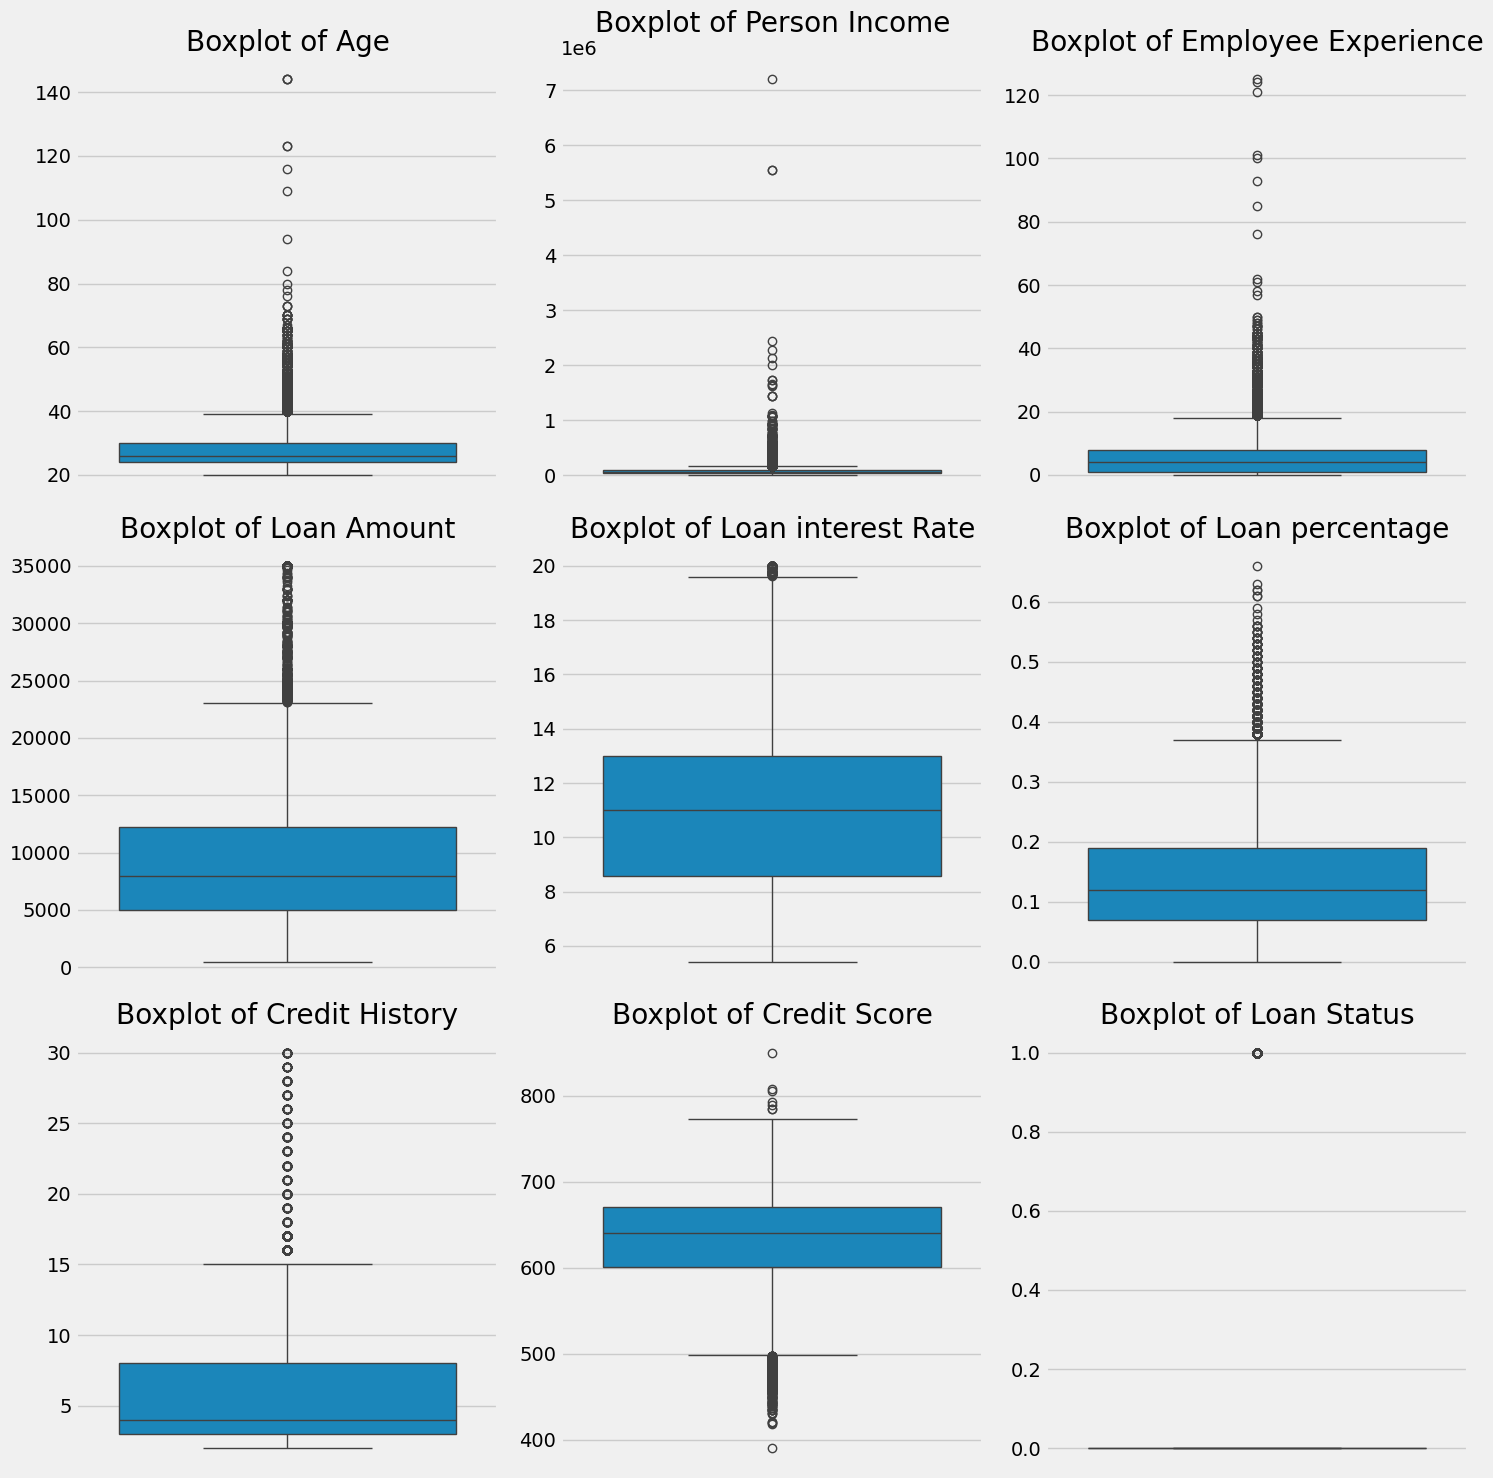

In [12]:
n_numerical_features = len(numerical_features)
n_cols = 3
n_rows = (n_numerical_features + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=data[feature])
    plt.title(f'Boxplot of {feature}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

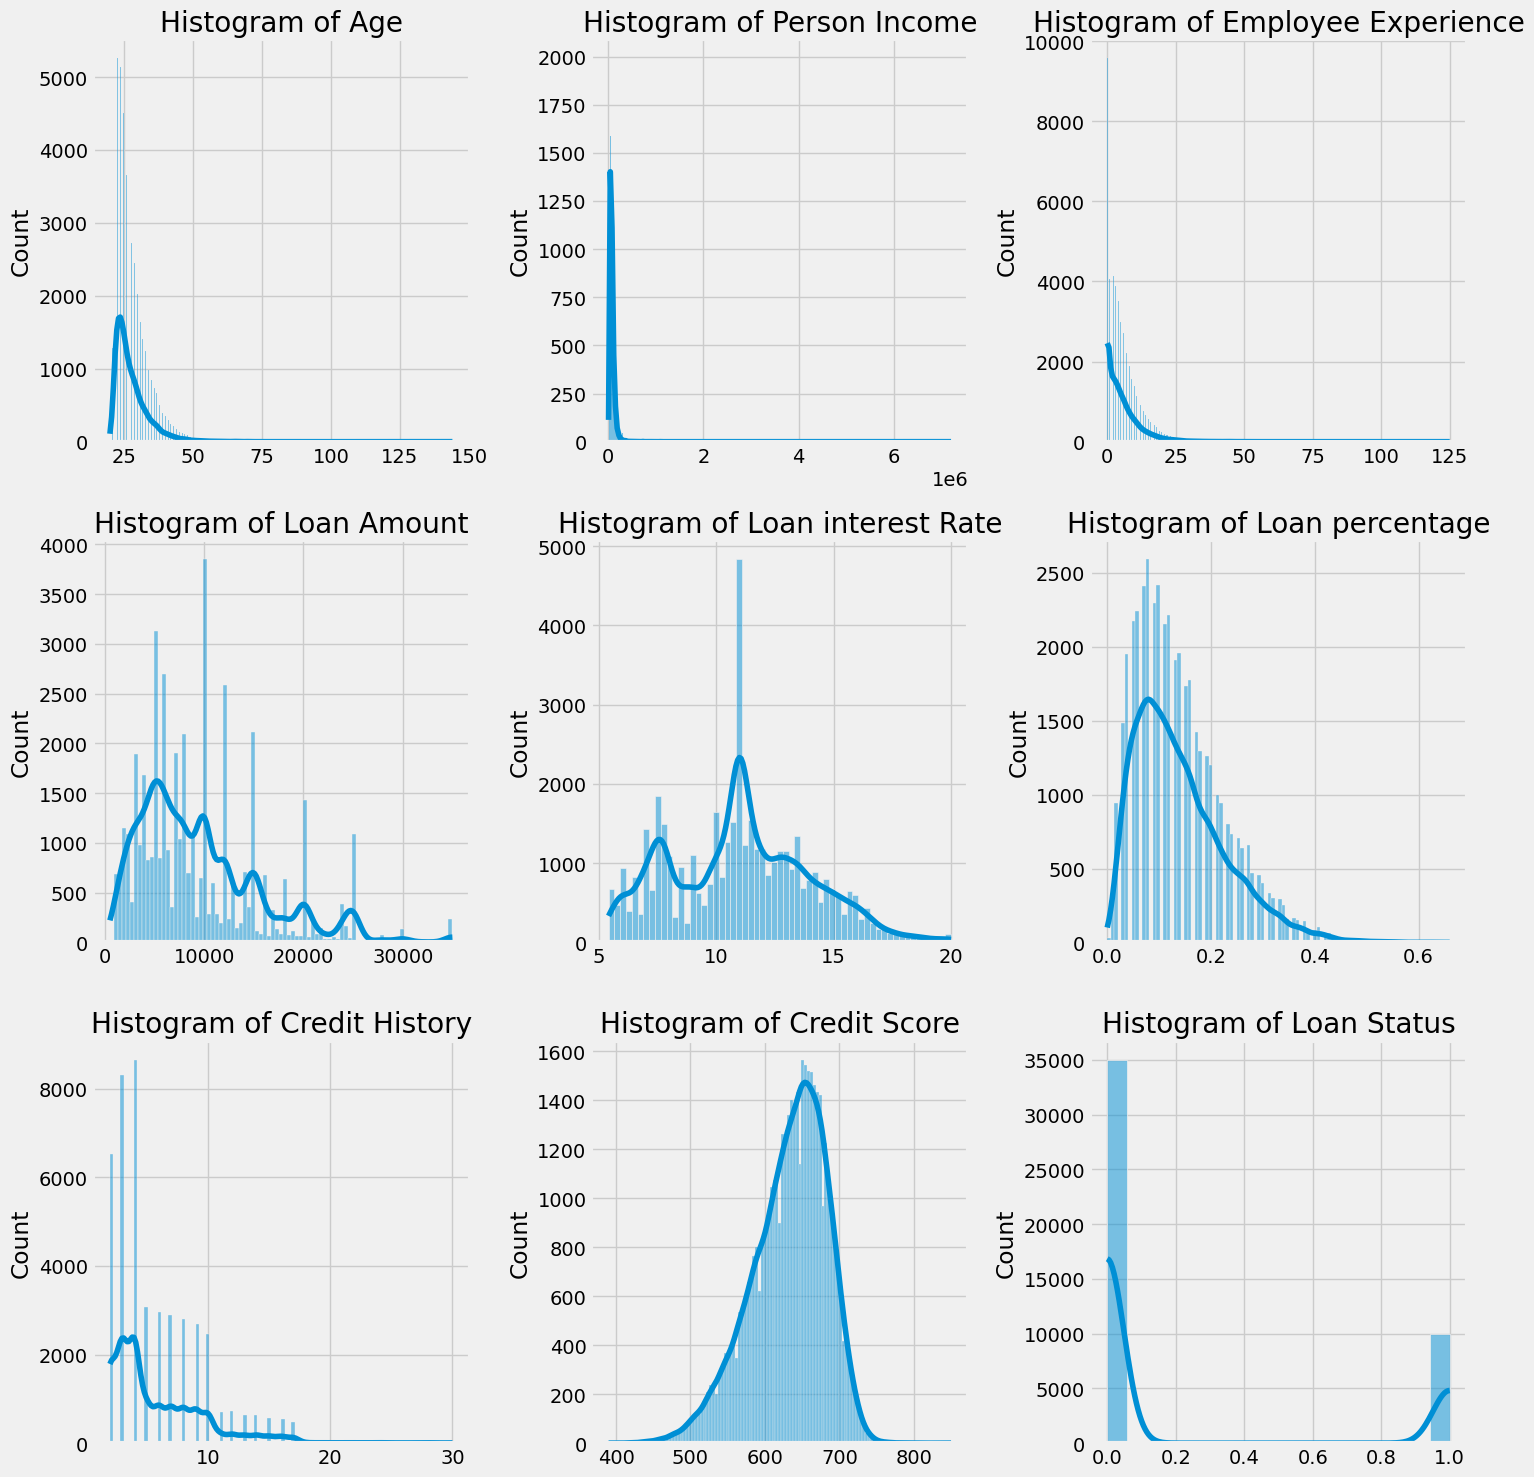

In [13]:
n_numerical_features = len(numerical_features)
n_cols = 3
n_rows = (n_numerical_features + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data[feature], kde=True)
    plt.title(f'Histogram of {feature}')
    plt.xlabel('')
plt.tight_layout()
plt.show()

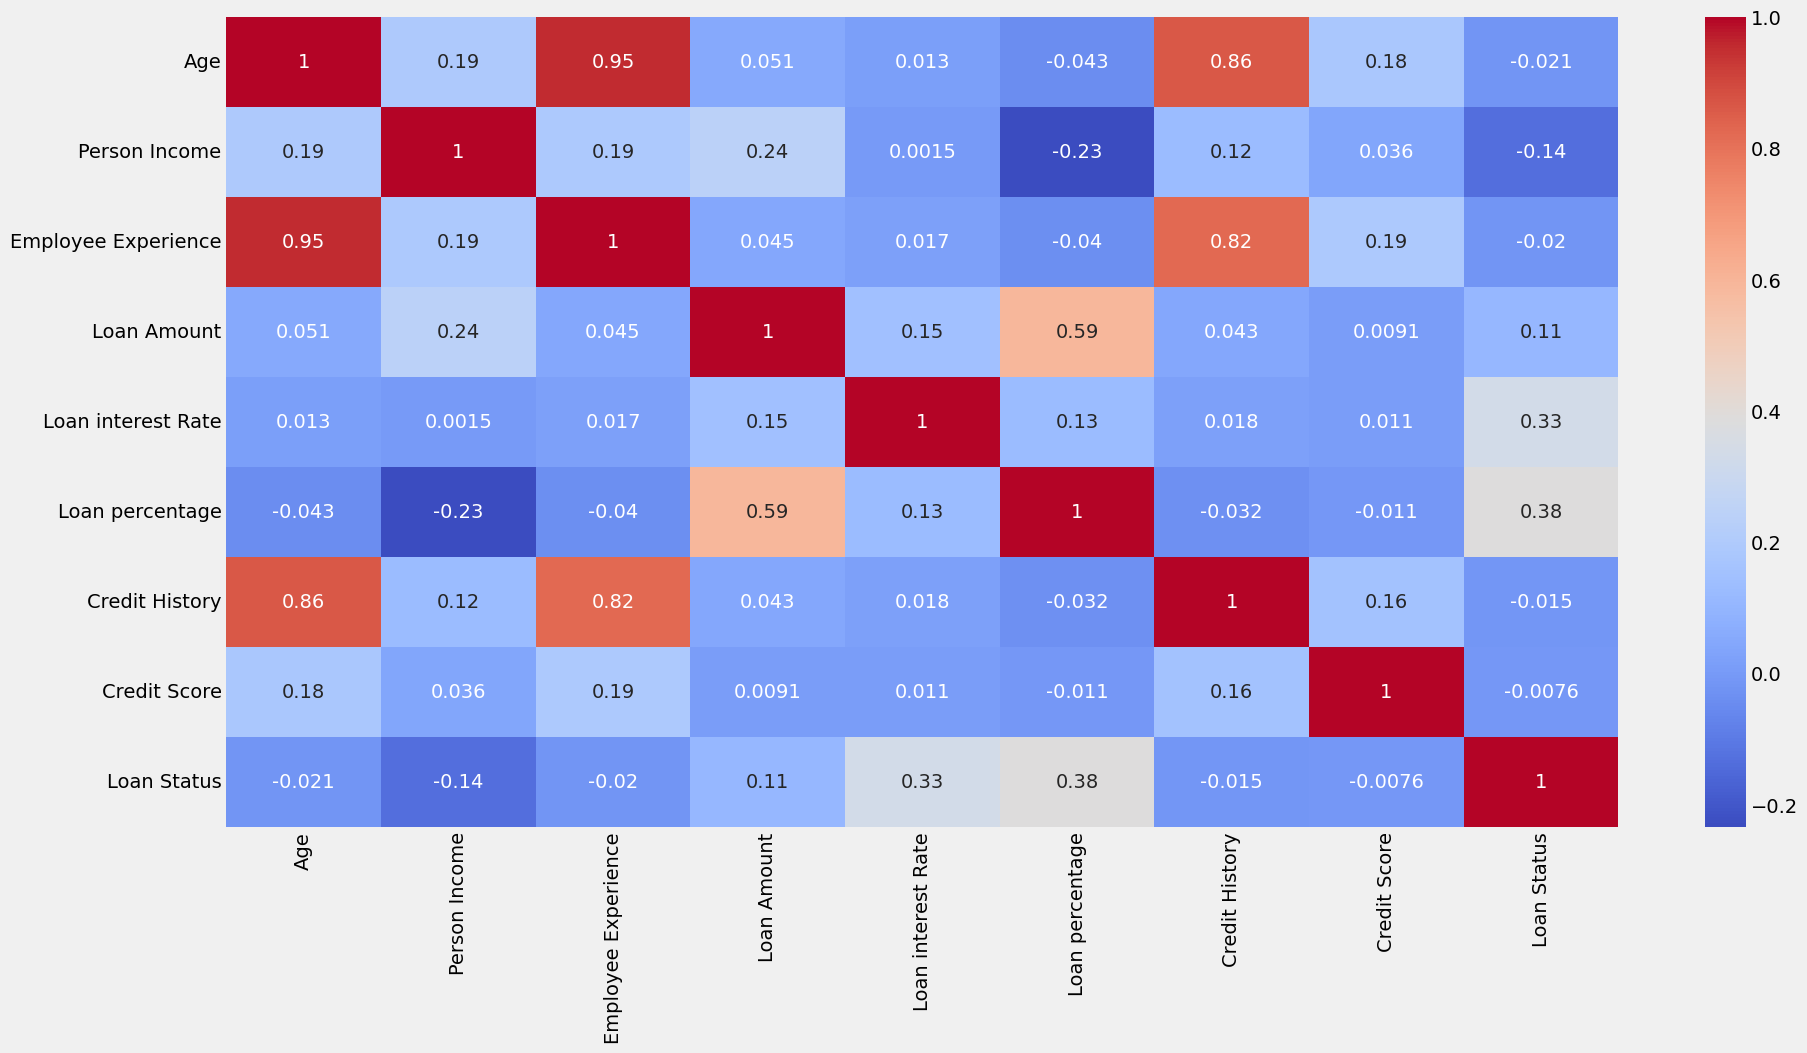

In [14]:
plt.figure(figsize = (20,10))
sns.heatmap(data[numerical_features].corr(), annot = True, cmap='coolwarm')
plt.show()

- From the boxplots visulize above, we can observe that
Age and Employee Experience variables have cler outliers that may happed due to errors in data entries and most of other numerical variable have extreme values.

- From the histogram distributions of variables above, we can observe that all the variables dosen't follow normal distribution. Age, Income, Experince, Loan amount, Loan percentage, Credit history distributions are right skeewed while Interest rate and Credit score varable inherit high kurtosis.

- From the correalation heatmap, we can observe that there exsist multicolineraity between features. Namely, high possitive relationship between Age and Expirence, high possitive relationship between credit history with Age and Experience, also moderate possitive relationship between Loan percentage and Loan Amount. Other variable have considerible low relationship with each other.

In [15]:
data[categorical_features].head()

,Gender,Education,Home Onwership,Loan Intent,Previous Loan
0,female,Master,RENT,PERSONAL,No
1,female,High School,OWN,EDUCATION,Yes
2,female,High School,MORTGAGE,MEDICAL,No
3,female,Bachelor,RENT,MEDICAL,No
4,male,Master,RENT,MEDICAL,No


In [16]:
gender_proportions = data['Gender'].value_counts(normalize=True).round(3)
display(gender_proportions)

cross_table_gender = pd.crosstab(data['Gender'], data['Loan Status'])
cross_table_gender_percentage = cross_table_gender.div(cross_table_gender.sum(axis=1), axis=0)
cross_table_gender_percentage.round(3)

Gender
male      0.552
female    0.448
Name: proportion, dtype: float64

Loan Status,0,1
Gender,,
female,0.778,0.222
male,0.778,0.222


In [17]:
education_proportions = data['Education'].value_counts(normalize=True).round(3)
display(education_proportions)

cross_table_Education = pd.crosstab(data['Education'], data['Loan Status'])
cross_table_gender_Education = cross_table_Education.div(cross_table_Education.sum(axis=1), axis=0)
cross_table_gender_Education.round(3)

Education
Bachelor       0.298
Associate      0.267
High School    0.266
Master         0.155
Doctorate      0.014
Name: proportion, dtype: float64

Loan Status,0,1
Education,,
Associate,0.780,0.220
Bachelor,0.775,0.225
Doctorate,0.771,0.229
High School,0.777,0.223
Master,0.782,0.218


In [18]:
home_ownership_proportions = data['Home Onwership'].value_counts(normalize=True).round(3)
display(home_ownership_proportions)

cross_table_Home_Onwership = pd.crosstab(data['Home Onwership'], data['Loan Status'])
cross_table_gender_Home_Onwership = cross_table_Home_Onwership.div(cross_table_Home_Onwership.sum(axis=1), axis=0)
cross_table_gender_Home_Onwership.round(3)

Home Onwership
RENT        0.521
MORTGAGE    0.411
OWN         0.066
OTHER       0.003
Name: proportion, dtype: float64

Loan Status,0,1
Home Onwership,,
MORTGAGE,0.884,0.116
OTHER,0.667,0.333
OWN,0.925,0.075
RENT,0.676,0.324


In [19]:
Loan_Intent_proportions = data['Loan Intent'].value_counts(normalize=True).round(3)
display(Loan_Intent_proportions)

cross_table_Loan_Intent_proportions = pd.crosstab(data['Loan Intent'], data['Loan Status'])
cross_table_gender_Loan_Intent_proportions = cross_table_Loan_Intent_proportions.div(cross_table_Loan_Intent_proportions.sum(axis=1), axis=0)
cross_table_gender_Loan_Intent_proportions.round(3)

Loan Intent
EDUCATION            0.203
MEDICAL              0.190
VENTURE              0.174
PERSONAL             0.168
DEBTCONSOLIDATION    0.159
HOMEIMPROVEMENT      0.106
Name: proportion, dtype: float64

Loan Status,0,1
Loan Intent,,
DEBTCONSOLIDATION,0.697,0.303
EDUCATION,0.830,0.170
HOMEIMPROVEMENT,0.737,0.263
MEDICAL,0.722,0.278
PERSONAL,0.799,0.201
VENTURE,0.856,0.144


In [20]:
Previous_Loan_proportions = data['Previous Loan'].value_counts(normalize=True).round(3)
display(Previous_Loan_proportions)

cross_table_Previous_Loan_proportions = pd.crosstab(data['Previous Loan'], data['Loan Status'])
cross_table_gender_Previous_Loan_proportions = cross_table_Previous_Loan_proportions.div(cross_table_Previous_Loan_proportions.sum(axis=1), axis=0)
cross_table_gender_Previous_Loan_proportions.round(3)

Previous Loan
Yes    0.508
No     0.492
Name: proportion, dtype: float64

Loan Status,0,1
Previous Loan,,
No,0.548,0.452
Yes,1.000,0.000


In [21]:
from scipy.stats import chi2_contingency

print('Chi-square Test Results for Categorical Variables vs. Loan Status:')
print('------------------------------------------------------------------')

for feature in categorical_features:
    if feature != 'Loan Status':
        print(f'\nAnalyzing: {feature} vs. Loan Status')
        contingency_table = pd.crosstab(data[feature], data['Loan Status'])
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)

        print(f'  Chi-square statistic: {chi2:.3f}')
        print(f'  P-value: {p_value:.3f}')
        print(f'  Degrees of freedom: {dof}')
        print(f'  Expected Frequencies:\n{pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns).round(2)}')

        alpha = 0.05
        if p_value < alpha:
            print(f'  Conclusion: Reject null hypothesis. There is a significant association between {feature} and Loan Status (p < {alpha}).')
        else:
            print(f'  Conclusion: Fail to reject null hypothesis. There is no significant association between {feature} and Loan Status (p >= {alpha}).')


Chi-square Test Results for Categorical Variables vs. Loan Status:
------------------------------------------------------------------

Analyzing: Gender vs. Loan Status
  Chi-square statistic: 0.012
  P-value: 0.914
  Degrees of freedom: 1
  Expected Frequencies:
Loan Status         0        1
Gender                        
female       15679.22  4479.78
male         19320.78  5520.22
  Conclusion: Fail to reject null hypothesis. There is no significant association between Gender and Loan Status (p >= 0.05).

Analyzing: Education vs. Loan Status
  Chi-square statistic: 2.016
  P-value: 0.733
  Degrees of freedom: 4
  Expected Frequencies:
Loan Status         0        1
Education                     
Associate     9355.11  2672.89
Bachelor     10421.44  2977.56
Doctorate      483.00   138.00
High School   9311.56  2660.44
Master        5428.89  1551.11
  Conclusion: Fail to reject null hypothesis. There is no significant association between Education and Loan Status (p >= 0.05).

Analyz

### Chi-square Test for Dependencies Between Categorical Features

In [22]:
from itertools import combinations
from scipy.stats import chi2_contingency

print('Chi-square Test Results for Dependencies Between Categorical Features:')
print('------------------------------------------------------------------')

features_for_inter_dependency = [f for f in categorical_features if f != 'Loan Status']

for feature1, feature2 in combinations(features_for_inter_dependency, 2):
    print(f'\nAnalyzing: {feature1} vs. {feature2}')
    contingency_table = pd.crosstab(data[feature1], data[feature2])

    if contingency_table.shape[0] <= 1 or contingency_table.shape[1] <= 1:
        print(f'  Skipping: Insufficient data for Chi-square test between {feature1} and {feature2}.')
        continue

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f'  Chi-square statistic: {chi2:.3f}')
    print(f'  P-value: {p_value:.3f}')
    print(f'  Degrees of freedom: {dof}')

    alpha = 0.05
    if p_value < alpha:
        print(f'  Conclusion: Reject null hypothesis. There is a significant dependency between {feature1} and {feature2} (p < {alpha}).')
    else:
        print(f'  Conclusion: Fail to reject null hypothesis. There is no significant dependency between {feature1} and {feature2} (p >= {alpha}).')


Chi-square Test Results for Dependencies Between Categorical Features:
------------------------------------------------------------------

Analyzing: Gender vs. Education
  Chi-square statistic: 1.123
  P-value: 0.891
  Degrees of freedom: 4
  Conclusion: Fail to reject null hypothesis. There is no significant dependency between Gender and Education (p >= 0.05).

Analyzing: Gender vs. Home Onwership
  Chi-square statistic: 0.420
  P-value: 0.936
  Degrees of freedom: 3
  Conclusion: Fail to reject null hypothesis. There is no significant dependency between Gender and Home Onwership (p >= 0.05).

Analyzing: Gender vs. Loan Intent
  Chi-square statistic: 2.324
  P-value: 0.803
  Degrees of freedom: 5
  Conclusion: Fail to reject null hypothesis. There is no significant dependency between Gender and Loan Intent (p >= 0.05).

Analyzing: Gender vs. Previous Loan
  Chi-square statistic: 0.020
  P-value: 0.889
  Degrees of freedom: 1
  Conclusion: Fail to reject null hypothesis. There is no s

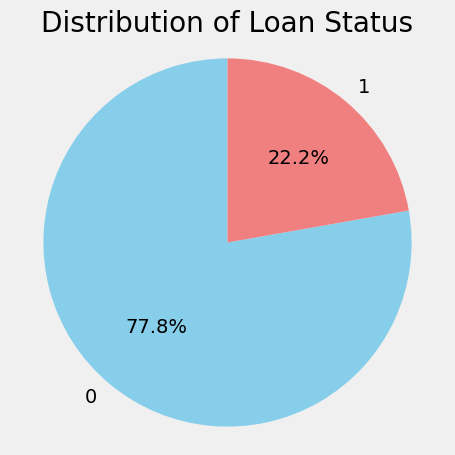

In [23]:
loan_status_counts = data['Loan Status'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(loan_status_counts, labels=loan_status_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Loan Status')
plt.axis('equal')
plt.show()

### 1. Distribution of Categorical Variables

The distribution of each categorical variable was examined to understand the composition of the dataset across different categories:

*   **Gender:** The dataset is composed of approximately 55.2% male and 44.8% female individuals.
*   **Education:** The education levels are distributed as follows: Bachelor (29.8%), Associate (26.7%), High School (26.6%), Master (15.5%), and Doctorate (1.4%).
*   **Home Ownership:** The majority of individuals either RENT (52.1%) or have a MORTGAGE (41.1%), with smaller proportions for OWN (6.6%) and OTHER (0.3%).
*   **Loan Intent:** The most common loan intents are EDUCATION (20.3%), MEDICAL (19.0%), VENTURE (17.4%), PERSONAL (16.8%), DEBTCONSOLIDATION (15.9%), and HOMEIMPROVEMENT (10.6%).
*   **Previous Loan:** The dataset is almost evenly split between individuals who have had a `Previous Loan` (50.8%) and those who have not (49.2%).

### 2. Association with Loan Status

Chi-square tests of independence were performed to assess the statistical association between each categorical variable and the `Loan Status` (0 = Not Approved, 1 = Approved). A significance level (alpha) of 0.05 was used.

*   **Gender vs. Loan Status:**
    *   **P-value:** 0.914
    *   **Conclusion:** There is **no significant association** between `Gender` and `Loan Status`. Both males and females show a similar loan approval rate (approximately 22.2%).

*   **Education vs. Loan Status:**
    *   **P-value:** 0.733
    *   **Conclusion:** There is **no significant association** between `Education` and `Loan Status`. Loan approval rates are consistent across different educational backgrounds (e.g., Associate: 22.0%, Bachelor: 22.5%, Doctorate: 22.9%, High School: 22.3%, Master: 21.8%).

*   **Home Ownership vs. Loan Status:**
    *   **P-value:** 0.000
    *   **Conclusion:** There is a **significant association** between `Home Ownership` and `Loan Status`. Approval rates vary considerably:
        *   MORTGAGE: ~11.6% approved
        *   OWN: ~7.5% approved
        *   OTHER: ~33.3% approved
        *   RENT: ~32.4% approved
      Individuals with `MORTGAGE` or `OWN` home ownership have notably lower loan approval rates compared to those who `RENT` or have `OTHER` arrangements.

*   **Loan Intent vs. Loan Status:**
    *   **P-value:** 0.000
    *   **Conclusion:** There is a **significant association** between `Loan Intent` and `Loan Status`. Approval rates differ based on the purpose of the loan:
        *   DEBTCONSOLIDATION: ~30.3% approved
        *   EDUCATION: ~17.0% approved
        *   HOMEIMPROVEMENT: ~26.3% approved
        *   MEDICAL: ~27.8% approved
        *   PERSONAL: ~20.1% approved
        *   VENTURE: ~14.4% approved
        `DEBTCONSOLIDATION` shows the highest approval rate, while `VENTURE` and `EDUCATION` have the lowest.

*   **Previous Loan vs. Loan Status:**
    *   **P-value:** 0.000
    *   **Conclusion:** There is a **significant association** between `Previous Loan` and `Loan Status`. This variable is a very strong predictor:
        *   No Previous Loan: ~45.2% approved
        *   Yes Previous Loan: ~0% approved
        This indicates that individuals who have had a previous loan are highly unlikely to get their current loan approved.

### 3. Dependencies Between Categorical Features

Chi-square tests were also conducted to examine inter-dependencies among the categorical features (excluding `Loan Status`).

*   **Gender:** `Gender` was found to be **independent** of all other categorical features (`Education`, `Home Ownership`, `Loan Intent`, `Previous Loan`), with all p-values > 0.05.

*   **Education:**
    *   **No significant dependency** with `Home Ownership` (p-value = 0.151).
    *   **Significant dependency** with `Loan Intent` (p-value = 0.000).
    *   **Significant dependency** with `Previous Loan` (p-value = 0.000).

*   **Home Ownership:**
    *   **Significant dependency** with `Loan Intent` (p-value = 0.000).
    *   **Significant dependency** with `Previous Loan` (p-value = 0.000).

*   **Loan Intent:**
    *   **Significant dependency** with `Previous Loan` (p-value = 0.000).

### Summary of Key Findings:

*   **Impact on Loan Status:** `Home Ownership`, `Loan Intent`, and `Previous Loan` are significantly associated with `Loan Status`. `Gender` and `Education` do not show a significant association.
*   **Strongest Predictor:** `Previous Loan` is a critical factor, with a nearly 0% approval rate for those who have had a previous loan.
*   **Inter-dependencies:** Most categorical features are interdependent, except for `Gender`, which is independent of all others, and `Education` and `Home Ownership`, which are also independent of each other.

These findings highlight important categorical variables that could be influential in predicting loan approval, particularly `Home Ownership`, `Loan Intent`, and `Previous Loan`.